In [ ]:
! pip3 install scikit-learn

In [58]:
import sklearn as sk
import pandas as pd

In [59]:
titanic = pd.read_csv('../Datasets/titanic_synthetic_5x.csv')

In [60]:
titanic['Survived'].value_counts()
print(titanic['Age'].isna().sum())


411


In [61]:
titanic['Age'] =titanic['Age'].fillna(titanic['Age'].mean())
print(titanic['Age'].isnull().sum())
print (titanic.head())

0
   PassengerId  Survived  Pclass                   Name     Sex        Age  \
0         2001         0       2   Anderson, Mr. Alex 1    male  44.370000   
1         2002         1       3  Bennett, Mr. Morgan 2    male  29.720000   
2         2003         0       3   Carter, Mr. Taylor 3    male  28.685325   
3         2004         0       1    Davis, Mr. Jordan 4    male   5.970000   
4         2005         0       3    Evans, Mrs. Casey 5  female  23.820000   

   SibSp  Parch     Ticket     Fare Cabin Embarked  
0      0      1  SYN-00001  19.3657   NaN        S  
1      0      1  SYN-00002  11.5649   NaN        C  
2      1      0  SYN-00003   4.9445  G158        S  
3      0      0  SYN-00004  87.3293   NaN        S  
4      0      0  SYN-00005  19.4430   NaN        S  


In [62]:
titanic = titanic.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])
titanic.dropna(subset=['Embarked'], inplace=True)



In [63]:
x = titanic.drop(columns=['Survived'])
y = titanic['Survived']

In [64]:
print(x.head())
print(y.head())

   Pclass     Sex        Age  SibSp  Parch     Fare Embarked
0       2    male  44.370000      0      1  19.3657        S
1       3    male  29.720000      0      1  11.5649        C
2       3    male  28.685325      1      0   4.9445        S
3       1    male   5.970000      0      0  87.3293        S
4       3  female  23.820000      0      0  19.4430        S
0    0
1    1
2    0
3    0
4    0
Name: Survived, dtype: int64


In [65]:
print(titanic.info())
print(titanic.head())

<class 'pandas.DataFrame'>
Index: 2067 entries, 0 to 2089
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  2067 non-null   int64  
 1   Pclass    2067 non-null   int64  
 2   Sex       2067 non-null   str    
 3   Age       2067 non-null   float64
 4   SibSp     2067 non-null   int64  
 5   Parch     2067 non-null   int64  
 6   Fare      2047 non-null   float64
 7   Embarked  2067 non-null   str    
dtypes: float64(2), int64(4), str(2)
memory usage: 145.3 KB
None
   Survived  Pclass     Sex        Age  SibSp  Parch     Fare Embarked
0         0       2    male  44.370000      0      1  19.3657        S
1         1       3    male  29.720000      0      1  11.5649        C
2         0       3    male  28.685325      1      0   4.9445        S
3         0       1    male   5.970000      0      0  87.3293        S
4         0       3  female  23.820000      0      0  19.4430        S


In [66]:
from sklearn.model_selection import train_test_split as ms

In [67]:
x_train, x_test, y_train, y_test = ms(x, y, test_size=0.2, random_state=42)
print(x_train.head())
print(y_train.head())
print(x_test.head())
print(y_test.head())

      Pclass     Sex        Age  SibSp  Parch     Fare Embarked
415        1  female  13.890000      1      2  61.1311        C
196        3    male  28.685325      1      1   5.9977        S
2035       1    male  28.685325      0      1  91.8675        C
1157       3  female  20.220000      0      1   5.4382        S
1806       2  female  41.600000      0      1   6.5217        S
415     0
196     1
2035    1
1157    1
1806    0
Name: Survived, dtype: int64
      Pclass     Sex    Age  SibSp  Parch     Fare Embarked
222        2    male  33.63      0      1  13.1541        S
556        3  female  51.27      0      0  10.3675        Q
1348       1    male  14.79      0      1  54.2974        Q
198        1  female  41.17      0      1  94.5024        C
29         2    male  37.66      1      0   8.3502        S
222     0
556     1
1348    1
198     0
29      0
Name: Survived, dtype: int64


In [77]:
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn.preprocessing import OneHotEncoder as ohe
from sklearn.compose import ColumnTransformer as ct
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
cat_cols = ['Sex', 'Embarked']


In [70]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
])

preprocessor = ct(
    transformers=[
        ('num', numeric_transformer, ['Age', 'Fare']),
        ('cat', ohe(sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
 )

In [71]:
x_train_final = preprocessor.fit_transform(x_train, y_train)
x_test_final = preprocessor.transform(x_test)

In [72]:
x_test_final.shape
x_train_final.shape

(1653, 10)

In [75]:
model = knn(n_neighbors=5)
model.fit(x_train_final, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
y_pre = model.predict(x_test_final)
print (accuracy_score(y_test, y_pre))


0.5483091787439613


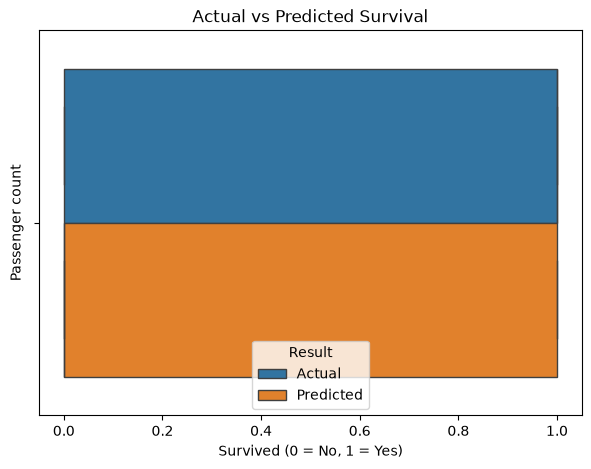

In [81]:
comparison = pd.DataFrame({
    'Actual': pd.Series(y_test).to_numpy(),
    'Predicted': y_pre
}).melt(var_name='Result', value_name='Survived')

plt.figure(figsize=(7, 5))
sns.boxplot(data=comparison, x='Survived', hue='Result')
plt.title('Actual vs Predicted Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Passenger count')
plt.show()